<a href="https://colab.research.google.com/github/keerthana-25/customizations_in_advance_deep_learning/blob/main/advanced_keras_pytorch_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Keras & PyTorch — Custom Components
### Based on Géron *Hands-On ML* Ch. 11, 12, 13
Each section implements the exact technique named in the assignment, in **both TensorFlow/Keras and PyTorch**, with a brief explanation of what it does and when to use it.
---
**Sections**
- i) Custom Learning Rate Scheduler (OneCycleScheduler)
- ii) Custom Dropout (MCAlphaDropout)
- iii) Custom Normalization (MaxNormDense)
- iv) TensorBoard
- v) Custom Loss Function (HuberLoss)
- vi) Custom Activation / Initializer / Regularizer / Constraint
- vii) Custom Metric (HuberMetric)
- viii) Custom Layers (ExponentialLayer, MyDense, AddGaussianNoise, LayerNormalization)
- ix) Custom Model (ResidualBlock + ResidualRegressor)
- x) Custom Optimizer (MyMomentumOptimizer)
- xi) Custom Training Loop (Fashion MNIST)
- xii) Weights & Biases Integration


## Setup

In [ ]:
!pip install -q tensorflow torch torchvision scikit-learn wandb
import warnings; warnings.filterwarnings('ignore')
print("Done")


Done


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, constraints, initializers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42); tf.random.set_seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"TF {tf.__version__}  |  PyTorch {torch.__version__}  |  device={DEVICE}")

# Shared dataset — California Housing (regression)
housing = fetch_california_housing()
X, y = housing.data.astype('float32'), housing.target.astype('float32')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_val   = scaler.transform(X_val).astype('float32')
X_test  = scaler.transform(X_test).astype('float32')
print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")


TF 2.19.0  |  PyTorch 2.10.0+cpu  |  device=cpu
Train (13209, 8)  Val (3303, 8)  Test (4128, 8)


---
## i) Custom Learning Rate Scheduler — OneCycleScheduler

**What it does:** The learning rate starts low, ramps up to a maximum, then decays back down — all within one training run. This is called "super-convergence" and often trains models faster and to better accuracy than a fixed LR.

**Reference:** Géron Ch. 11 — `OneCycleScheduler` callback example.

**When to use:** Any time you want faster convergence with fewer epochs. Works well with SGD or Adam.


### i.1 — TensorFlow / Keras

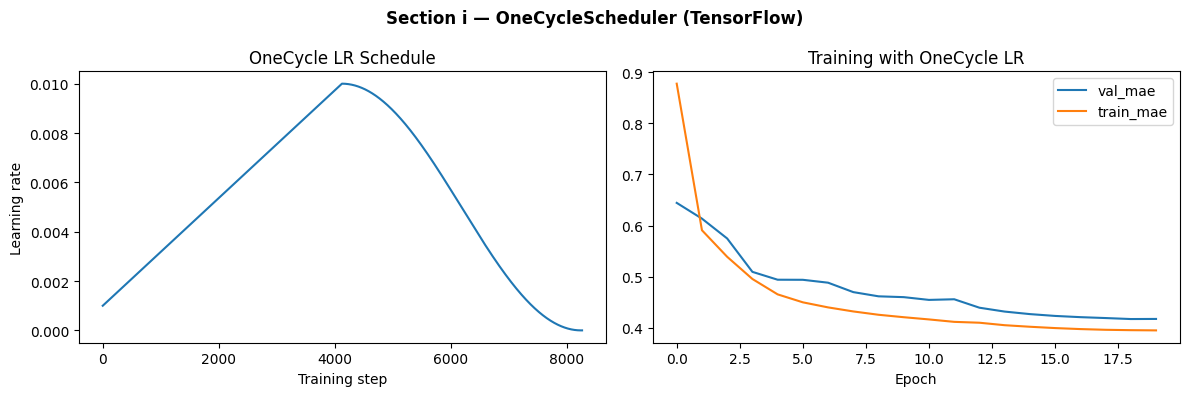

Best val MAE: 0.4171


In [ ]:
class OneCycleScheduler(keras.callbacks.Callback):
    """
    OneCycle LR policy (Leslie Smith, 2018).
    Phase 1: LR increases linearly from max_lr/10 to max_lr  (first half of training)
    Phase 2: LR decreases via cosine from max_lr to max_lr/1000 (second half)
    Exactly as shown in Géron Ch.11.
    """
    def __init__(self, iterations, max_lr=1e-3):
        super().__init__()
        self.iterations = iterations
        self.max_lr     = max_lr
        self.start_lr   = max_lr / 10
        self.end_lr     = max_lr / 1e4
        self._step      = 0
        self.lrs        = []

    def _interpolate(self, a, b, frac):
        return a + (b - a) * frac

    def on_batch_begin(self, batch, logs=None):
        half = self.iterations // 2
        if self._step < half:
            lr = self._interpolate(self.start_lr, self.max_lr, self._step / half)
        else:
            frac = (self._step - half) / (self.iterations - half)
            lr   = self.end_lr + 0.5 * (self.max_lr - self.end_lr) * (1 + np.cos(np.pi * frac))
        self.model.optimizer.learning_rate = float(lr)
        self.lrs.append(lr)

    def on_batch_end(self, batch, logs=None):
        self._step += 1

# ── Build a simple regression model ──
def make_model():
    m = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.SGD(), loss='mse', metrics=['mae'])
    return m

EPOCHS = 20
N_ITER = (len(X_train) // 32) * EPOCHS
scheduler = OneCycleScheduler(iterations=N_ITER, max_lr=1e-2)

model = make_model()
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=32,
                    callbacks=[scheduler], verbose=0)

# Plot the LR schedule
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(scheduler.lrs)
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Learning rate')
axes[0].set_title('OneCycle LR Schedule')

axes[1].plot(history.history['val_mae'], label='val_mae')
axes[1].plot(history.history['mae'],     label='train_mae')
axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].set_title('Training with OneCycle LR')
plt.suptitle('Section i — OneCycleScheduler (TensorFlow)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Best val MAE: {min(history.history['val_mae']):.4f}")


### i.2 — PyTorch

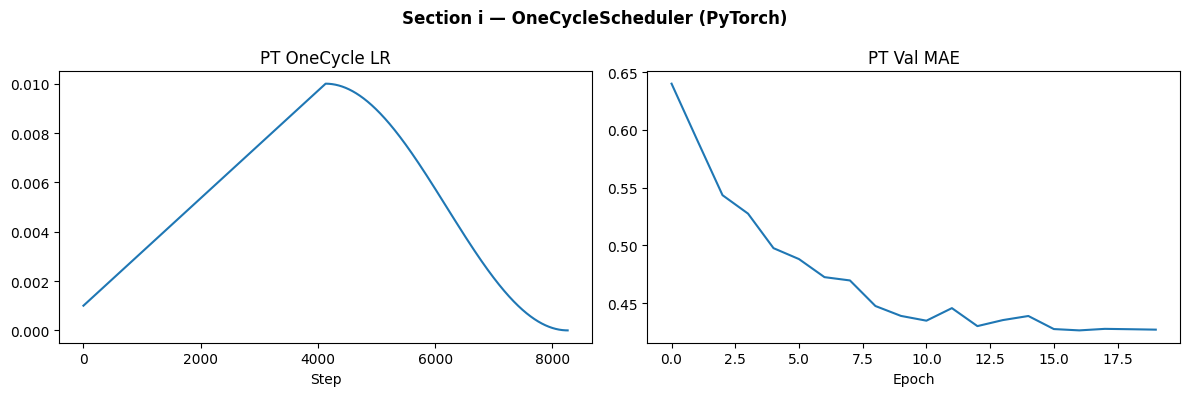

Best val MAE: 0.4263


In [ ]:
class OneCycleLR_PT(optim.lr_scheduler._LRScheduler):
    """
    PyTorch version of OneCycle scheduler.
    Inherits from _LRScheduler so it plugs into the standard .step() call.
    """
    def __init__(self, optimizer, max_lr, total_steps, last_epoch=-1):
        self.max_lr      = max_lr
        self.start_lr    = max_lr / 10
        self.end_lr      = max_lr / 1e4
        self.total_steps = total_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        t    = self.last_epoch
        half = self.total_steps // 2
        if t < half:
            lr = self.start_lr + (self.max_lr - self.start_lr) * t / half
        else:
            frac = (t - half) / max(1, self.total_steps - half)
            lr   = self.end_lr + 0.5 * (self.max_lr - self.end_lr) * (1 + np.cos(np.pi * frac))
        return [lr for _ in self.base_lrs]

# ── PyTorch training ──
def make_pt_model():
    return nn.Sequential(
        nn.Linear(8, 64), nn.ReLU(),
        nn.Linear(64, 32), nn.ReLU(),
        nn.Linear(32, 1)
    ).to(DEVICE)

Xt = torch.FloatTensor(X_train); yt = torch.FloatTensor(y_train)
Xv = torch.FloatTensor(X_val);   yv = torch.FloatTensor(y_val)
ld_tr = DataLoader(TensorDataset(Xt, yt), batch_size=32, shuffle=True)
ld_va = DataLoader(TensorDataset(Xv, yv), batch_size=32)

EPOCHS_PT = 20
TOTAL_STEPS = len(ld_tr) * EPOCHS_PT

pt_model = make_pt_model()
pt_opt   = optim.SGD(pt_model.parameters(), lr=1e-3)
pt_sched = OneCycleLR_PT(pt_opt, max_lr=1e-2, total_steps=TOTAL_STEPS)
crit     = nn.MSELoss()

lrs_pt, val_maes_pt = [], []
step = 0
for ep in range(EPOCHS_PT):
    pt_model.train()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pt_opt.zero_grad()
        crit(pt_model(xb).squeeze(), yb).backward()
        pt_opt.step(); pt_sched.step()
        lrs_pt.append(pt_opt.param_groups[0]['lr'])
    pt_model.eval()
    with torch.no_grad():
        mae = [(pt_model(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
               for xb, yb in ld_va]
    val_maes_pt.append(np.mean(mae))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lrs_pt);      axes[0].set_title('PT OneCycle LR'); axes[0].set_xlabel('Step')
axes[1].plot(val_maes_pt); axes[1].set_title('PT Val MAE');     axes[1].set_xlabel('Epoch')
plt.suptitle('Section i — OneCycleScheduler (PyTorch)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Best val MAE: {min(val_maes_pt):.4f}")


---
## ii) Custom Dropout — MCAlphaDropout

**What it does:** A dropout variant designed for **SELU** (Self-Normalizing) networks. Standard dropout breaks the self-normalizing property of SELU. Alpha Dropout instead scales and shifts the dropped values to preserve the mean and variance of SELU's output.

The "MC" prefix means you can keep dropout **active at inference time** (Monte Carlo Dropout) to get **uncertainty estimates** — run the model N times and use the spread of predictions as a confidence measure.

**Reference:** Géron Ch. 11 — `MCAlphaDropout`.


### ii.1 — TensorFlow / Keras

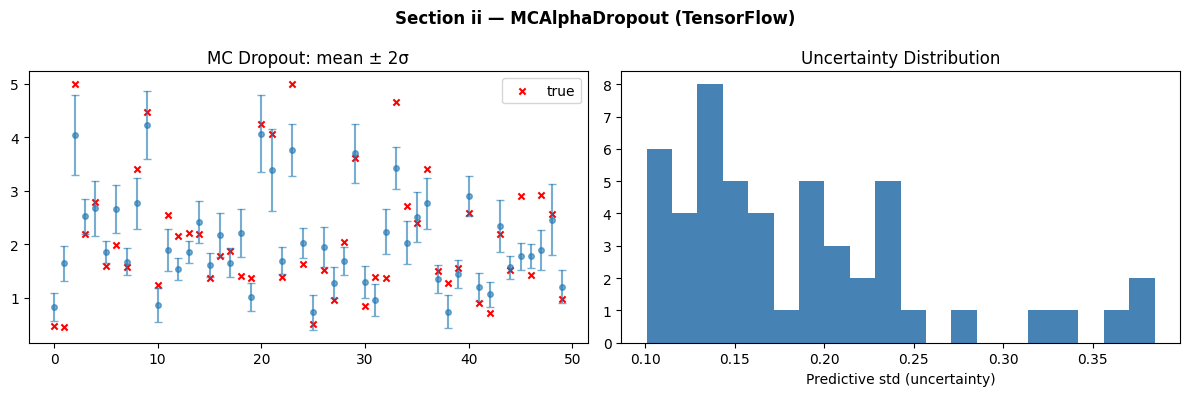

Val MAE: 0.5716


In [ ]:
class MCAlphaDropout(layers.Layer):
    """
    Alpha Dropout for SELU networks (Géron Ch.11).
    - Preserves mean and variance after dropout (unlike standard dropout).
    - Keeps dropout active at inference when called with training=True,
      enabling Monte Carlo uncertainty estimation.
    """
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate  = rate
        # SELU constants
        self.alpha = 1.6732631921768188
        self.scale = 1.0507009873554804

    def call(self, inputs, training=None):
        if training:
            keep      = 1.0 - self.rate
            alpha_p   = -self.alpha * self.scale          # value injected for dropped units
            mask      = tf.random.uniform(tf.shape(inputs)) < keep
            kept      = tf.cast(mask, inputs.dtype)
            x         = inputs * kept + alpha_p * (1.0 - kept)
            # Affine transform to restore mean=0, std=1
            a = (keep + alpha_p**2 * keep * (1 - keep)) ** (-0.5)
            b = -a * (1 - keep) * alpha_p
            return a * x + b
        return inputs

    def get_config(self):
        return {**super().get_config(), 'rate': self.rate}

# ── Model using SELU + MCAlphaDropout ──
mc_model = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(64, activation='selu', kernel_initializer='lecun_normal'),
    MCAlphaDropout(rate=0.1),
    layers.Dense(32, activation='selu', kernel_initializer='lecun_normal'),
    MCAlphaDropout(rate=0.1),
    layers.Dense(1),
])
mc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
h_mc = mc_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=20, batch_size=32, verbose=0)

# Monte Carlo inference — run 100 stochastic forward passes
X_sample = tf.constant(X_test[:50])
mc_preds = np.stack([mc_model(X_sample, training=True).numpy().squeeze()
                     for _ in range(100)], axis=0)  # shape (100, 50)
mc_mean  = mc_preds.mean(axis=0)
mc_std   = mc_preds.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(range(50), mc_mean, yerr=2*mc_std, fmt='o', ms=4, capsize=3, alpha=0.6)
axes[0].scatter(range(50), y_test[:50], marker='x', color='red', s=20, label='true')
axes[0].set_title('MC Dropout: mean ± 2σ'); axes[0].legend()

axes[1].hist(mc_std, bins=20, color='steelblue')
axes[1].set_xlabel('Predictive std (uncertainty)'); axes[1].set_title('Uncertainty Distribution')
plt.suptitle('Section ii — MCAlphaDropout (TensorFlow)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Val MAE: {min(h_mc.history['val_mae']):.4f}")


### ii.2 — PyTorch

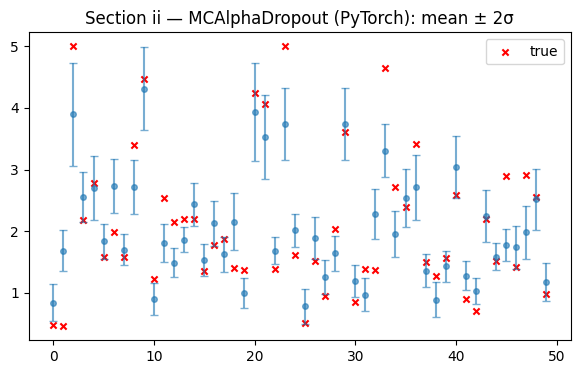

In [ ]:
class MCAlphaDropout_PT(nn.Module):
    """PyTorch MCAlphaDropout — same logic as TF version."""
    def __init__(self, rate=0.1):
        super().__init__()
        self.rate  = rate
        self.alpha = 1.6732631921768188
        self.scale = 1.0507009873554804

    def forward(self, x, mc=False):
        if self.training or mc:
            keep    = 1.0 - self.rate
            alpha_p = -self.alpha * self.scale
            mask    = (torch.rand_like(x) < keep).float()
            x       = x * mask + alpha_p * (1.0 - mask)
            a = (keep + alpha_p**2 * keep * (1 - keep)) ** (-0.5)
            b = -a * (1 - keep) * alpha_p
            return a * x + b
        return x

class SNN_PT(nn.Module):
    """Self-normalizing network using SELU + MCAlphaDropout."""
    def __init__(self):
        super().__init__()
        self.fc1  = nn.Linear(8, 64);  self.fc2 = nn.Linear(64, 32); self.out = nn.Linear(32, 1)
        self.drop = MCAlphaDropout_PT(0.1)
        # LeCun Normal init required for SELU SNNs
        for fc in [self.fc1, self.fc2]:
            nn.init.kaiming_normal_(fc.weight, nonlinearity='linear')
            nn.init.zeros_(fc.bias)

    def forward(self, x, mc=False):
        x = self.drop(torch.selu(self.fc1(x)), mc=mc)
        x = self.drop(torch.selu(self.fc2(x)), mc=mc)
        return self.out(x)

snn = SNN_PT().to(DEVICE)
opt_snn = optim.Adam(snn.parameters(), 1e-3); crit_mse = nn.MSELoss()
for ep in range(20):
    snn.train()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_snn.zero_grad(); crit_mse(snn(xb).squeeze(), yb).backward(); opt_snn.step()

# Monte Carlo inference
snn.eval()
Xs = torch.FloatTensor(X_test[:50]).to(DEVICE)
with torch.no_grad():
    mc_pt = torch.stack([snn(Xs, mc=True).squeeze() for _ in range(100)]).cpu().numpy()
mc_mean_pt = mc_pt.mean(0); mc_std_pt = mc_pt.std(0)

plt.figure(figsize=(7, 4))
plt.errorbar(range(50), mc_mean_pt, yerr=2*mc_std_pt, fmt='o', ms=4, capsize=3, alpha=0.6)
plt.scatter(range(50), y_test[:50], marker='x', color='red', s=20, label='true')
plt.title('Section ii — MCAlphaDropout (PyTorch): mean ± 2σ'); plt.legend(); plt.show()


---
## iii) Custom Normalization — MaxNormDense

**What it does:** A Dense layer where, after every gradient update, each neuron's incoming weight vector is clipped so its L2-norm does not exceed `max_norm`. This is a **weight constraint**, not a batch-level normalization.

**Reference:** Géron Ch. 11 — `MaxNormDense`.

**When to use:** When using large learning rates or strong dropout and you want to prevent weights from growing unbounded.


### iii.1 — TensorFlow / Keras

Max column norm in layer 0 kernel: 1.0000  (should be ≤ 1.0)
Val MAE: 0.3855


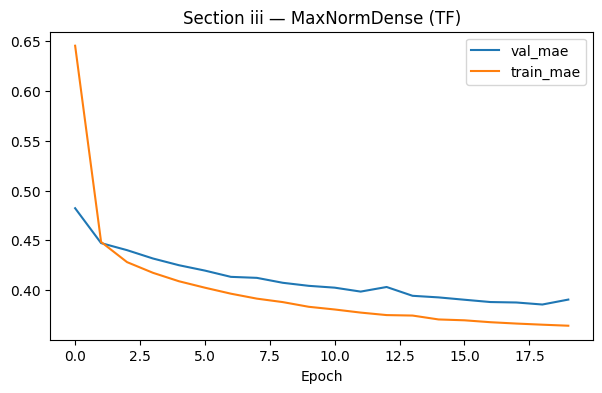

In [ ]:
class MaxNormDense(layers.Layer):
    """
    Dense layer with max-norm weight constraint (Géron Ch.11).
    After each update: clip each weight vector so ||w||₂ ≤ max_norm.
    """
    def __init__(self, units, max_norm=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units    = units
        self.max_norm = max_norm

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        # Project weights onto max-norm ball (column-wise)
        norms   = tf.norm(self.kernel, axis=0, keepdims=True)
        desired = tf.clip_by_value(norms, 0, self.max_norm)
        self.kernel.assign(self.kernel * (desired / (norms + 1e-8)))
        return tf.matmul(inputs, self.kernel) + self.bias

    def get_config(self):
        return {**super().get_config(), 'units': self.units, 'max_norm': self.max_norm}

# ── Demo ──
mn_model = keras.Sequential([
    keras.Input(shape=(8,)),
    MaxNormDense(64, max_norm=1.0), layers.Activation('relu'),
    MaxNormDense(32, max_norm=1.0), layers.Activation('relu'),
    layers.Dense(1),
])
mn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
h_mn = mn_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=20, batch_size=32, verbose=0)

# Verify: all column norms should be ≤ 1.0
norms_after = tf.norm(mn_model.layers[0].kernel, axis=0).numpy()
print(f"Max column norm in layer 0 kernel: {norms_after.max():.4f}  (should be ≤ 1.0)")
print(f"Val MAE: {min(h_mn.history['val_mae']):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(h_mn.history['val_mae'], label='val_mae')
plt.plot(h_mn.history['mae'],     label='train_mae')
plt.legend(); plt.xlabel('Epoch'); plt.title('Section iii — MaxNormDense (TF)'); plt.show()


### iii.2 — PyTorch

Max row norm in PT layer 0: 1.0000  (should be ≤ 1.0)
Best val MAE: 0.3808


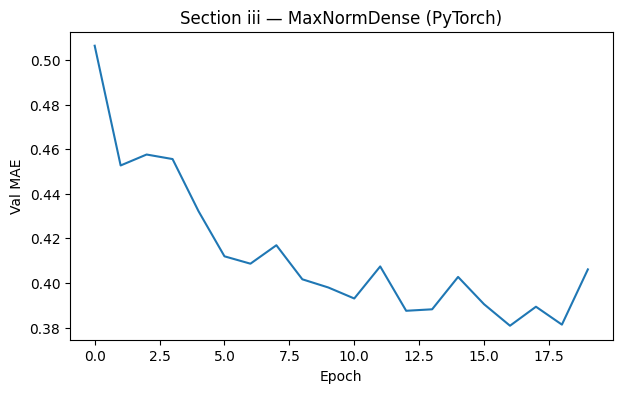

In [ ]:
class MaxNormLinear(nn.Module):
    """PyTorch Linear layer with max-norm constraint on columns of weight matrix."""
    def __init__(self, in_f, out_f, max_norm=1.0):
        super().__init__()
        self.linear   = nn.Linear(in_f, out_f)
        self.max_norm = max_norm

    def forward(self, x):
        # Clip column norms of weight matrix before forward pass
        with torch.no_grad():
            norms   = self.linear.weight.norm(dim=1, keepdim=True).clamp(min=1e-8)
            desired = norms.clamp(max=self.max_norm)
            self.linear.weight.mul_(desired / norms)
        return self.linear(x)

mn_pt = nn.Sequential(
    MaxNormLinear(8, 64), nn.ReLU(),
    MaxNormLinear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
).to(DEVICE)

opt_mn = optim.Adam(mn_pt.parameters(), 1e-3); val_maes_mn = []
for ep in range(20):
    mn_pt.train()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_mn.zero_grad(); crit_mse(mn_pt(xb).squeeze(), yb).backward(); opt_mn.step()
    mn_pt.eval()
    with torch.no_grad():
        mae = [(mn_pt(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
               for xb, yb in ld_va]
    val_maes_mn.append(np.mean(mae))

# Verify norms
norms_pt = mn_pt[0].linear.weight.norm(dim=1).detach().cpu().numpy()
print(f"Max row norm in PT layer 0: {norms_pt.max():.4f}  (should be ≤ 1.0)")
print(f"Best val MAE: {min(val_maes_mn):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(val_maes_mn); plt.title('Section iii — MaxNormDense (PyTorch)')
plt.xlabel('Epoch'); plt.ylabel('Val MAE'); plt.show()


---
## iv) TensorBoard

**What it does:** Visualizes training metrics (loss, accuracy), model graph, weight histograms, and learning rate curves in an interactive browser dashboard.

**Reference:** Géron Ch. 11 — TensorBoard callback usage.

**How to launch in Colab:**
```python
%load_ext tensorboard
%tensorboard --logdir /tmp/tb_logs
```


### iv.1 — TensorFlow / Keras

In [ ]:
import os, datetime
LOG_DIR = "/tmp/tb_logs/" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(LOG_DIR, exist_ok=True)

tb_model = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
])
tb_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir       = LOG_DIR,
    histogram_freq= 1,       # log weight histograms every epoch
    write_graph   = True,    # log the model graph
    update_freq   = 'epoch', # log metrics every epoch
)

h_tb = tb_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs     = 20,
    batch_size = 32,
    verbose    = 0,
    callbacks  = [
        tensorboard_cb,
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    ]
)
print(f"Logs saved to: {LOG_DIR}")
print(f"Val MAE: {min(h_tb.history['val_mae']):.4f}")
print()
print("Launch TensorBoard with:")
print("  %load_ext tensorboard")
print(f"  %tensorboard --logdir {LOG_DIR}")


Logs saved to: /tmp/tb_logs/20260417_035007
Val MAE: 0.3871

Launch TensorBoard with:
  %load_ext tensorboard
  %tensorboard --logdir /tmp/tb_logs/20260417_035007


### iv.2 — PyTorch

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import copy

PT_LOG_DIR = "/tmp/tb_logs_pt/" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
writer = SummaryWriter(PT_LOG_DIR)

tb_pt = nn.Sequential(
    nn.Linear(8, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
).to(DEVICE)

# Log the model graph
dummy_input = torch.zeros(1, 8).to(DEVICE)
writer.add_graph(tb_pt, dummy_input)

opt_tb = optim.Adam(tb_pt.parameters(), 1e-3)
best_mae = float('inf'); best_wts = None

for ep in range(20):
    tb_pt.train(); tr_loss = 0
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_tb.zero_grad()
        loss = crit_mse(tb_pt(xb).squeeze(), yb)
        loss.backward(); opt_tb.step()
        tr_loss += loss.item()
    tr_loss /= len(ld_tr)

    tb_pt.eval()
    with torch.no_grad():
        val_mae = np.mean([(tb_pt(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
                           for xb, yb in ld_va])

    # Log scalars
    writer.add_scalar('Loss/train', tr_loss, ep)
    writer.add_scalar('MAE/val',    val_mae,  ep)
    # Log weight histograms
    for name, param in tb_pt.named_parameters():
        writer.add_histogram(name, param.data, ep)

    if val_mae < best_mae:
        best_mae = val_mae; best_wts = copy.deepcopy(tb_pt.state_dict())

writer.close()
tb_pt.load_state_dict(best_wts)
print(f"Logs saved to: {PT_LOG_DIR}")
print(f"Best val MAE: {best_mae:.4f}")
print()
print("Launch TensorBoard with:")
print("  %load_ext tensorboard")
print(f"  %tensorboard --logdir {PT_LOG_DIR}")


Logs saved to: /tmp/tb_logs_pt/20260417_035028
Best val MAE: 0.3866

Launch TensorBoard with:
  %load_ext tensorboard
  %tensorboard --logdir /tmp/tb_logs_pt/20260417_035028


---
## v) Custom Loss Function — HuberLoss

**What it does:** The Huber loss is a combination of MSE (for small errors) and MAE (for large errors):
- `|error| ≤ δ` → `0.5 × error²`  (MSE: smooth gradient near zero)
- `|error| > δ` → `δ × (|error| − δ/2)` (MAE: doesn't blow up on outliers)

**Reference:** Géron Ch. 12 — `HuberLoss` class.

**When to use:** Regression when the target has outliers. More robust than MSE, more stable than MAE.


### v.1 — TensorFlow / Keras

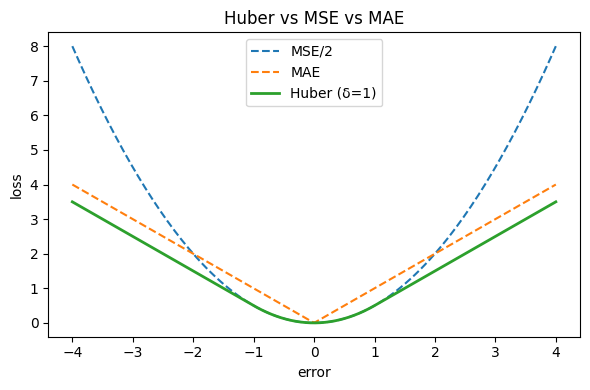

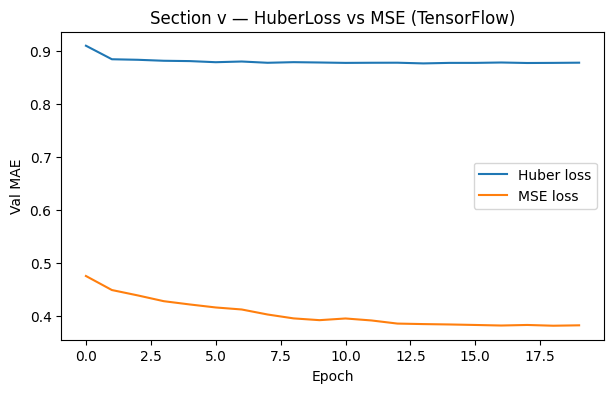

Huber val MAE: 0.8771
MSE   val MAE: 0.3813


In [ ]:
class HuberLoss(keras.losses.Loss):
    """
    Huber Loss (Géron Ch.12).
    Combines MSE for small residuals and MAE for large residuals.
    δ (delta) controls the boundary between the two regimes.
    """
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error    = y_true - y_pred
        is_small = tf.abs(error) <= self.delta
        sq_loss  = 0.5 * tf.square(error)
        lin_loss = self.delta * tf.abs(error) - 0.5 * self.delta**2
        return tf.where(is_small, sq_loss, lin_loss)

    def get_config(self):
        return {**super().get_config(), 'delta': self.delta}

# ── Visualise the loss shape ──
err = np.linspace(-4, 4, 200)
mse_vals   = 0.5 * err**2
huber_vals = np.where(np.abs(err) <= 1.0, 0.5*err**2, 1.0*np.abs(err) - 0.5)

plt.figure(figsize=(6, 4))
plt.plot(err, mse_vals,   '--', label='MSE/2')
plt.plot(err, np.abs(err),'--', label='MAE')
plt.plot(err, huber_vals, lw=2, label='Huber (δ=1)')
plt.legend(); plt.title('Huber vs MSE vs MAE'); plt.xlabel('error'); plt.ylabel('loss')
plt.tight_layout(); plt.show()

# ── Train with Huber loss ──
def make_model():
    m = keras.Sequential([keras.Input(shape=(8,)),
                          layers.Dense(64, activation='relu'),
                          layers.Dense(32, activation='relu'),
                          layers.Dense(1)])
    return m

m_huber = make_model()
m_huber.compile(optimizer='adam', loss=HuberLoss(delta=1.0), metrics=['mae'])
h_huber = m_huber.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=20, batch_size=32, verbose=0)

m_mse = make_model()
m_mse.compile(optimizer='adam', loss='mse', metrics=['mae'])
h_mse = m_mse.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=20, batch_size=32, verbose=0)

plt.figure(figsize=(7, 4))
plt.plot(h_huber.history['val_mae'], label='Huber loss')
plt.plot(h_mse.history['val_mae'],   label='MSE loss')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Val MAE')
plt.title('Section v — HuberLoss vs MSE (TensorFlow)'); plt.show()
print(f"Huber val MAE: {min(h_huber.history['val_mae']):.4f}")
print(f"MSE   val MAE: {min(h_mse.history['val_mae']):.4f}")


### v.2 — PyTorch

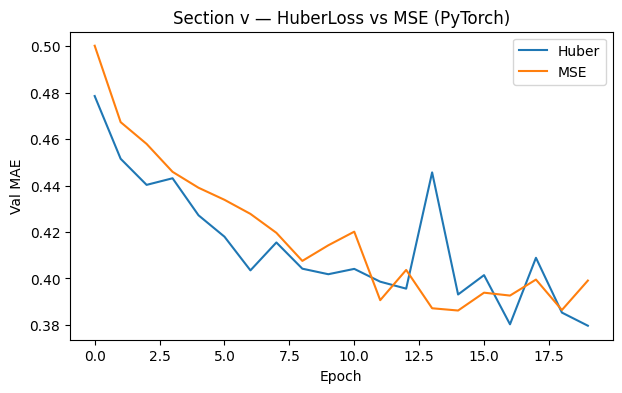

Huber: 0.3797  |  MSE: 0.3862


In [ ]:
class HuberLoss_PT(nn.Module):
    """PyTorch Huber Loss built from scratch (torch also has F.huber_loss built in)."""
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        err      = y_true - y_pred
        is_small = err.abs() <= self.delta
        sq_loss  = 0.5 * err**2
        lin_loss = self.delta * err.abs() - 0.5 * self.delta**2
        return torch.where(is_small, sq_loss, lin_loss).mean()

def train_pt_loss(loss_fn, epochs=20):
    m = nn.Sequential(nn.Linear(8,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1)).to(DEVICE)
    opt = optim.Adam(m.parameters(), 1e-3); val_maes = []
    for ep in range(epochs):
        m.train()
        for xb, yb in ld_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss_fn(m(xb).squeeze(), yb).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            mae = [(m(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
                   for xb, yb in ld_va]
        val_maes.append(np.mean(mae))
    return val_maes

maes_huber_pt = train_pt_loss(HuberLoss_PT(1.0))
maes_mse_pt   = train_pt_loss(nn.MSELoss())

plt.figure(figsize=(7,4))
plt.plot(maes_huber_pt, label='Huber'); plt.plot(maes_mse_pt, label='MSE')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Val MAE')
plt.title('Section v — HuberLoss vs MSE (PyTorch)'); plt.show()
print(f"Huber: {min(maes_huber_pt):.4f}  |  MSE: {min(maes_mse_pt):.4f}")


---
## vi) Custom Activation, Initializer, Regularizer, Kernel Constraint

**Reference:** Géron Ch. 12 — `leaky_relu`, `my_glorot_initializer`, `MyL1Regularizer`, `my_positive_weights`.

Four separate concepts all demonstrated together:
| Component | Géron example | What it controls |
|---|---|---|
| Activation | `leaky_relu` | How neurons fire |
| Initializer | `my_glorot_initializer` | Starting weight values |
| Regularizer | `MyL1Regularizer` | Penalty added to loss |
| Constraint | `my_positive_weights` | Hard limit on weight values |


### vi.1 — TensorFlow / Keras

Min weight in layer 0: 0.000000  (should be ≥ 0 due to constraint)
Val MAE: 0.4641


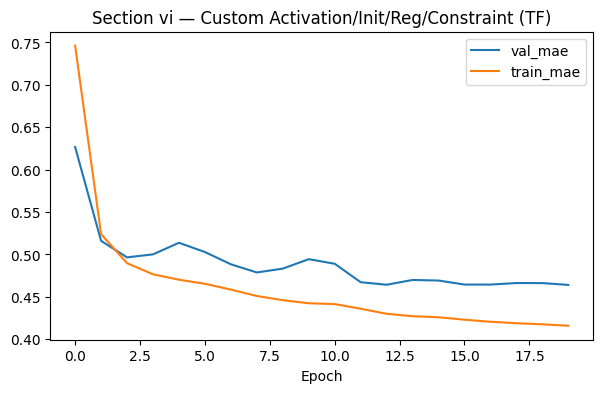

In [ ]:
# ── Custom Activation: Leaky ReLU ──
def leaky_relu(z, alpha=0.2):
    """
    Leaky ReLU: f(x) = x if x > 0, else alpha*x.
    Fixes the 'dying ReLU' problem — neurons with all-negative inputs
    still produce a small gradient (alpha) so they can recover.
    """
    return tf.maximum(alpha * z, z)

# ── Custom Initializer: Glorot with adjustable gain ──
class MyGlorotInitializer(initializers.Initializer):
    """
    Glorot/Xavier initialization scaled by a gain factor.
    Standard Glorot: gain=1.0. For ReLU layers use gain=sqrt(2) (same as He init).
    """
    def __init__(self, gain=1.0, seed=None):
        self.gain = gain; self.seed = seed

    def __call__(self, shape, dtype=tf.float32):
        fan_in  = shape[0] if len(shape) == 1 else np.prod(shape[:-1])
        fan_out = shape[-1]
        limit   = self.gain * np.sqrt(6.0 / (fan_in + fan_out))
        return tf.random.uniform(shape, minval=-limit, maxval=limit, dtype=dtype, seed=self.seed)

    def get_config(self):
        return {'gain': self.gain, 'seed': self.seed}

# ── Custom Regularizer: L1 ──
class MyL1Regularizer(regularizers.Regularizer):
    """
    L1 regularization: adds factor * sum(|w|) to the loss.
    Promotes sparsity — many weights are driven exactly to zero,
    effectively doing feature selection.
    """
    def __init__(self, factor=0.01):
        self.factor = factor

    def __call__(self, weights):
        return self.factor * tf.reduce_sum(tf.abs(weights))

    def get_config(self):
        return {'factor': self.factor}

# ── Custom Constraint: positive weights ──
class MyPositiveWeights(constraints.Constraint):
    """
    Clips all weights to be non-negative after each gradient update.
    Use for monotone models where inputs should only increase the output.
    """
    def __call__(self, w):
        return tf.clip_by_value(w, 0.0, float('inf'))

    def get_config(self):
        return {}

# ── Use all four in one model ──
vi_model = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(
        64,
        activation=leaky_relu,                      # custom activation
        kernel_initializer=MyGlorotInitializer(gain=np.sqrt(2)),  # custom init
        kernel_regularizer=MyL1Regularizer(1e-4),   # custom regularizer
        kernel_constraint=MyPositiveWeights(),       # custom constraint
    ),
    layers.Dense(32, activation=leaky_relu,
                 kernel_regularizer=MyL1Regularizer(1e-4)),
    layers.Dense(1),
])
vi_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
h_vi = vi_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=20, batch_size=32, verbose=0)

# Verify: all weights in layer 0 should be >= 0 (positive constraint)
w0 = vi_model.layers[0].kernel.numpy()
print(f"Min weight in layer 0: {w0.min():.6f}  (should be ≥ 0 due to constraint)")
print(f"Val MAE: {min(h_vi.history['val_mae']):.4f}")

plt.figure(figsize=(7,4))
plt.plot(h_vi.history['val_mae'], label='val_mae')
plt.plot(h_vi.history['mae'],     label='train_mae')
plt.legend(); plt.xlabel('Epoch')
plt.title('Section vi — Custom Activation/Init/Reg/Constraint (TF)'); plt.show()


### vi.2 — PyTorch

Min weight in fc1: 0.000000  (≥ 0 due to constraint)
Best val MAE: 0.6063


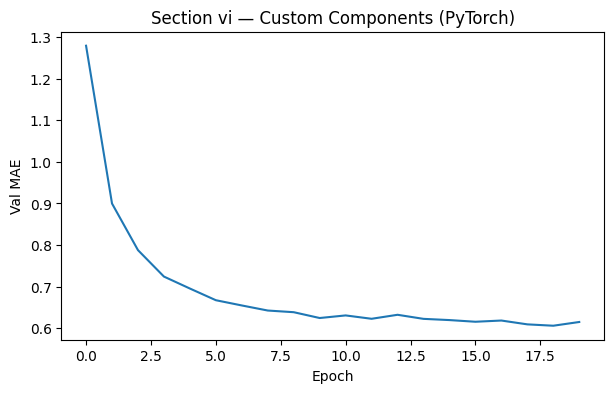

In [ ]:
# Custom activation
def leaky_relu_pt(x, alpha=0.2):
    return torch.where(x > 0, x, alpha * x)

# Custom initializer function
def my_glorot_init(module, gain=1.0):
    if isinstance(module, nn.Linear):
        fan_in, fan_out = module.weight.shape[1], module.weight.shape[0]
        limit = gain * np.sqrt(6.0 / (fan_in + fan_out))
        nn.init.uniform_(module.weight, -limit, limit)
        nn.init.zeros_(module.bias)

# Custom L1 regularization penalty
def my_l1_reg(model, factor=1e-4):
    return factor * sum(p.abs().sum() for p in model.parameters())

# Custom positive-weights constraint applied after each step
def apply_positive_constraint(model):
    with torch.no_grad():
        for p in model.parameters():
            p.clamp_(min=0.0)

class VI_Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)
        # Apply custom initializer
        self.apply(lambda m: my_glorot_init(m, gain=np.sqrt(2)))

    def forward(self, x):
        x = leaky_relu_pt(self.fc1(x))
        x = leaky_relu_pt(self.fc2(x))
        return self.out(x)

vi_pt = VI_Net().to(DEVICE)
opt_vi = optim.Adam(vi_pt.parameters(), 1e-3); val_maes_vi = []

for ep in range(20):
    vi_pt.train()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_vi.zero_grad()
        loss = crit_mse(vi_pt(xb).squeeze(), yb) + my_l1_reg(vi_pt, 1e-4)  # L1 reg
        loss.backward(); opt_vi.step()
        apply_positive_constraint(vi_pt)  # positive-weights constraint
    vi_pt.eval()
    with torch.no_grad():
        mae = [(vi_pt(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
               for xb, yb in ld_va]
    val_maes_vi.append(np.mean(mae))

w0_pt = vi_pt.fc1.weight.detach().cpu().numpy()
print(f"Min weight in fc1: {w0_pt.min():.6f}  (≥ 0 due to constraint)")
print(f"Best val MAE: {min(val_maes_vi):.4f}")

plt.figure(figsize=(7,4))
plt.plot(val_maes_vi); plt.title('Section vi — Custom Components (PyTorch)')
plt.xlabel('Epoch'); plt.ylabel('Val MAE'); plt.show()


---
## vii) Custom Metric — HuberMetric

**What it does:** Tracks the Huber loss as a metric (not a loss). Metrics are stateful — they accumulate values across batches and reset at each epoch.

**Reference:** Géron Ch. 12 — `HuberMetric` class.

**Key difference from a loss:** A loss is used for gradient computation. A metric is only for monitoring — it won't affect training.

The three methods to implement:
- `update_state()`: called each batch, accumulates totals
- `result()`: returns the scalar metric value for the epoch
- `reset_state()`: resets accumulators at epoch start


### vii.1 — TensorFlow / Keras

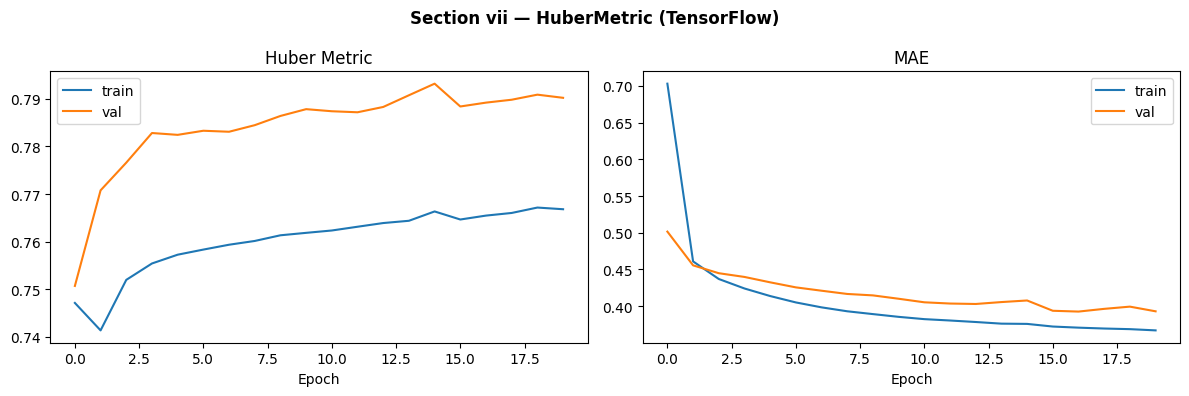

In [ ]:
class HuberMetric(keras.metrics.Metric):
    """
    Running Huber loss as a monitoring metric (Géron Ch.12).
    Accumulates total Huber loss and sample count across all batches,
    then returns the mean at the end of each epoch.
    """
    def __init__(self, delta=1.0, name='huber_metric', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta      = delta
        self.total      = self.add_weight(name='total', initializer='zeros')
        self.count      = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        err    = y_true - y_pred
        loss   = tf.where(tf.abs(err) <= self.delta,
                          0.5 * tf.square(err),
                          self.delta * tf.abs(err) - 0.5 * self.delta**2)
        self.total.assign_add(tf.reduce_sum(loss))
        self.count.assign_add(tf.cast(tf.size(loss), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.)
        self.count.assign(0.)

    def get_config(self):
        return {**super().get_config(), 'delta': self.delta}

# ── Use as a metric alongside MAE ──
m_metric = make_model()
m_metric.compile(optimizer='adam', loss='mse',
                 metrics=[HuberMetric(delta=1.0), 'mae'])
h_metric = m_metric.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=20, batch_size=32, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_metric.history['huber_metric'],     label='train')
axes[0].plot(h_metric.history['val_huber_metric'], label='val')
axes[0].set_title('Huber Metric'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(h_metric.history['mae'],     label='train')
axes[1].plot(h_metric.history['val_mae'], label='val')
axes[1].set_title('MAE'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.suptitle('Section vii — HuberMetric (TensorFlow)', fontweight='bold')
plt.tight_layout(); plt.show()


### vii.2 — PyTorch

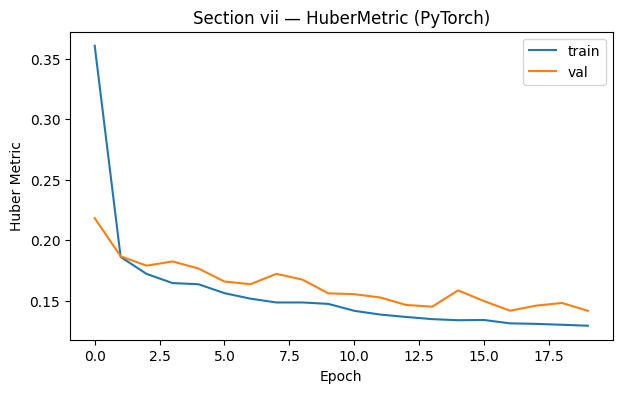

Best val Huber metric: 0.1418


In [ ]:
class HuberMetric_PT:
    """
    Stateful Huber metric for PyTorch training loops.
    Call update() each batch, result() at epoch end, reset() at epoch start.
    """
    def __init__(self, delta=1.0):
        self.delta = delta; self.reset()

    def reset(self):
        self.total = 0.0; self.count = 0

    def update(self, pred, target):
        err  = target - pred
        loss = torch.where(err.abs() <= self.delta,
                           0.5 * err**2,
                           self.delta * err.abs() - 0.5 * self.delta**2)
        self.total += loss.sum().item()
        self.count += loss.numel()

    def result(self):
        return self.total / max(self.count, 1)

# ── Training loop with HuberMetric ──
m_mt = nn.Sequential(nn.Linear(8,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1)).to(DEVICE)
opt_mt = optim.Adam(m_mt.parameters(), 1e-3)
huber_m = HuberMetric_PT(1.0)
tr_hubm, va_hubm = [], []

for ep in range(20):
    m_mt.train(); huber_m.reset()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_mt.zero_grad()
        pred = m_mt(xb).squeeze()
        crit_mse(pred, yb).backward(); opt_mt.step()
        huber_m.update(pred.detach(), yb)
    tr_hubm.append(huber_m.result())

    m_mt.eval(); huber_m.reset()
    with torch.no_grad():
        for xb, yb in ld_va:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            huber_m.update(m_mt(xb).squeeze(), yb)
    va_hubm.append(huber_m.result())

plt.figure(figsize=(7,4))
plt.plot(tr_hubm, label='train'); plt.plot(va_hubm, label='val')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Huber Metric')
plt.title('Section vii — HuberMetric (PyTorch)'); plt.show()
print(f"Best val Huber metric: {min(va_hubm):.4f}")


---
## viii) Custom Layers

**Reference:** Géron Ch. 12 — `exponential_layer`, `MyDense`, `AddGaussianNoise`, `LayerNormalization`.

Each layer demonstrates a different aspect of the custom layer API:
| Layer | Demonstrates |
|---|---|
| `ExponentialLayer` | Stateless layer (no weights) |
| `MyDense` | Layer with weights (`build` + `call`) |
| `AddGaussianNoise` | Training-only behavior |
| `LayerNormalization` | Layer with learnable scale/shift |


### viii.1 — TensorFlow / Keras

In [ ]:
# ── 1. ExponentialLayer — stateless, no weights ──
class ExponentialLayer(layers.Layer):
    """Applies exp(x). Useful as output layer when predicting positive quantities."""
    def call(self, inputs):
        return tf.exp(inputs)

# ── 2. MyDense — dense layer built from scratch ──
class MyDense(layers.Layer):
    """
    Reproduces keras.Dense exactly, showing how build/call work.
    build(): called once when first input shape is known — creates weights.
    call():  called every forward pass.
    """
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        out = tf.matmul(inputs, self.kernel) + self.bias
        return self.activation(out) if self.activation else out

    def get_config(self):
        return {**super().get_config(), 'units': self.units,
                'activation': keras.activations.serialize(self.activation)}

# ── 3. AddGaussianNoise — training-only behavior ──
class AddGaussianNoise(layers.Layer):
    """
    Adds zero-mean Gaussian noise during training only (no effect at inference).
    Acts as an implicit data augmentation / regularizer inside the model.
    """
    def __init__(self, stddev=0.1, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            return inputs + tf.random.normal(tf.shape(inputs), stddev=self.stddev, dtype=inputs.dtype)
        return inputs

    def get_config(self):
        return {**super().get_config(), 'stddev': self.stddev}

# ── 4. LayerNormalization — learnable scale and shift ──
class MyLayerNorm(layers.Layer):
    """
    Layer Normalization: normalize each sample across its feature dimension.
    output = gamma * (x - mean) / (std + eps) + beta
    gamma and beta are learned per-feature scalars.
    """
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma',
            shape=(input_shape[-1],),
            initializer='ones',
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        mean, var = tf.nn.moments(inputs, axes=[-1], keepdims=True)
        return self.gamma * (inputs - mean) / tf.sqrt(var + self.eps) + self.beta

    def get_config(self):
        return {**super().get_config(), 'eps': self.eps}

# ── Use all four in one model ──
viii_model = keras.Sequential([
    keras.Input(shape=(8,)),
    AddGaussianNoise(stddev=0.05),
    MyDense(64),
    MyLayerNorm(),
    layers.Activation('relu'),
    MyDense(32),
    MyLayerNorm(),
    layers.Activation('relu'),
    layers.Dense(1),
    ExponentialLayer(),   # positive output
])
viii_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
viii_model.summary()
h_viii = viii_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=20, batch_size=32, verbose=0)
print(f"Val MAE: {min(h_viii.history['val_mae']):.4f}")


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ add_gaussian_noise              │ (None, 8)              │             0 │
│ (AddGaussianNoise)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense (MyDense)              │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_layer_norm (MyLayerNorm)     │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_1 (MyDense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_layer_norm_1 (MyLayerNorm)   │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ exponential_layer               │ (None, 1)              │             0 │
│ (ExponentialLayer)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

Val MAE: 0.3857


### viii.2 — PyTorch

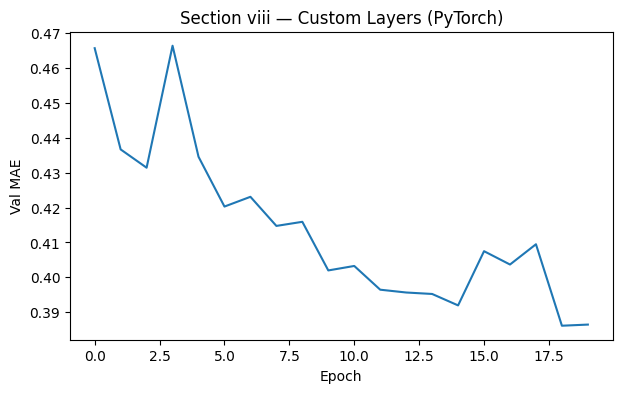

Best val MAE: 0.3861


In [ ]:
class ExponentialLayer_PT(nn.Module):
    def forward(self, x): return torch.exp(x)

class MyDense_PT(nn.Module):
    """Dense layer from scratch — shows how nn.Linear works internally."""
    def __init__(self, in_f, out_f, activation=None):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_f, out_f)); nn.init.xavier_uniform_(self.weight)
        self.bias   = nn.Parameter(torch.zeros(out_f))
        self.act    = activation
    def forward(self, x):
        out = x @ self.weight + self.bias
        return self.act(out) if self.act else out

class AddGaussianNoise_PT(nn.Module):
    def __init__(self, std=0.1): super().__init__(); self.std = std
    def forward(self, x):
        return x + torch.randn_like(x) * self.std if self.training else x

class MyLayerNorm_PT(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta  = nn.Parameter(torch.zeros(dim))
        self.eps   = eps
    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        var  = x.var(-1, keepdim=True, unbiased=False)
        return self.gamma * (x - mean) / (var + self.eps).sqrt() + self.beta

class VIII_Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise = AddGaussianNoise_PT(0.05)
        self.fc1   = MyDense_PT(8, 64, activation=torch.relu)
        self.ln1   = MyLayerNorm_PT(64)
        self.fc2   = MyDense_PT(64, 32, activation=torch.relu)
        self.ln2   = MyLayerNorm_PT(32)
        self.out   = nn.Linear(32, 1)
        self.exp   = ExponentialLayer_PT()
    def forward(self, x):
        x = self.noise(x)
        x = self.ln1(self.fc1(x))
        x = self.ln2(self.fc2(x))
        return self.exp(self.out(x))

viii_pt = VIII_Net().to(DEVICE)
opt_viii = optim.Adam(viii_pt.parameters(), 1e-3); val_maes_viii = []
for ep in range(20):
    viii_pt.train()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_viii.zero_grad(); crit_mse(viii_pt(xb).squeeze(), yb).backward(); opt_viii.step()
    viii_pt.eval()
    with torch.no_grad():
        mae = [(viii_pt(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
               for xb, yb in ld_va]
    val_maes_viii.append(np.mean(mae))

plt.figure(figsize=(7,4))
plt.plot(val_maes_viii); plt.title('Section viii — Custom Layers (PyTorch)')
plt.xlabel('Epoch'); plt.ylabel('Val MAE'); plt.show()
print(f"Best val MAE: {min(val_maes_viii):.4f}")


---
## ix) Custom Model — ResidualBlock + ResidualRegressor

**What it does:** Subclassing `keras.Model` to build a **residual network** for regression. The residual (skip) connection adds the input directly to the block's output: `output = F(x) + x`.

**Reference:** Géron Ch. 12 — `ResidualBlock` and `ResidualRegressor`.

**Why it matters:** Skip connections prevent vanishing gradients in deep networks, allowing training of very deep architectures. This is the core idea behind ResNet.


### ix.1 — TensorFlow / Keras

Val MAE: 0.8746


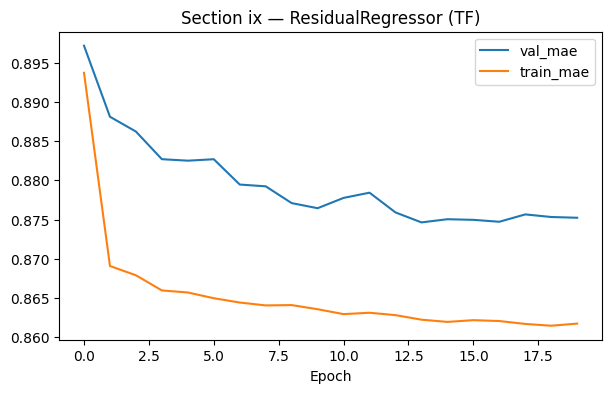

In [ ]:
class ResidualBlock(layers.Layer):
    """
    Two Dense layers with a skip connection.
    If input and output dimensions differ, a projection (1x1 linear) is used.
    output = ReLU(Dense(Dense(x)) + projection(x))
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units  = units
        self.dense1 = layers.Dense(units, activation='relu')
        self.dense2 = layers.Dense(units)
        self.proj   = None  # created in build if needed

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.proj = layers.Dense(self.units)
        super().build(input_shape)

    def call(self, inputs):
        skip = self.proj(inputs) if self.proj else inputs
        return tf.nn.relu(self.dense2(self.dense1(inputs)) + skip)

    def get_config(self):
        return {**super().get_config(), 'units': self.units}


class ResidualRegressor(keras.Model):
    """
    Regression model built from stacked ResidualBlocks.
    Subclasses keras.Model for full forward-pass control.
    """
    def __init__(self, n_blocks=3, units=64, **kwargs):
        super().__init__(**kwargs)
        self.hidden      = layers.Dense(units, activation='relu')
        self.res_blocks  = [ResidualBlock(units) for _ in range(n_blocks)]
        self.output_layer= layers.Dense(1)

    def call(self, inputs):
        x = self.hidden(inputs)
        for block in self.res_blocks:
            x = block(x)
        return self.output_layer(x)

    def get_config(self):
        # Required for model serialisation
        return {'n_blocks': len(self.res_blocks), 'units': self.hidden.units}


res_model = ResidualRegressor(n_blocks=3, units=64)
res_model.compile(optimizer='adam', loss=HuberLoss(1.0), metrics=['mae'])
h_res = res_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=20, batch_size=32, verbose=0)
print(f"Val MAE: {min(h_res.history['val_mae']):.4f}")

plt.figure(figsize=(7,4))
plt.plot(h_res.history['val_mae'], label='val_mae')
plt.plot(h_res.history['mae'],     label='train_mae')
plt.legend(); plt.xlabel('Epoch')
plt.title('Section ix — ResidualRegressor (TF)'); plt.show()


### ix.2 — PyTorch

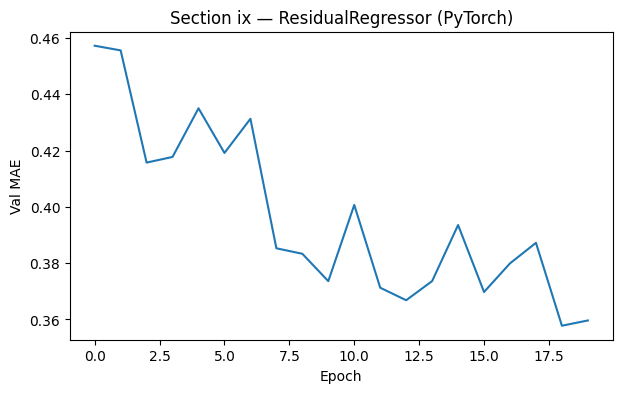

Best val MAE: 0.3578


In [ ]:
class ResidualBlock_PT(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.fc1  = nn.Linear(in_f,  out_f)
        self.fc2  = nn.Linear(out_f, out_f)
        self.proj = nn.Linear(in_f, out_f) if in_f != out_f else nn.Identity()

    def forward(self, x):
        skip = self.proj(x)
        return torch.relu(self.fc2(torch.relu(self.fc1(x))) + skip)


class ResidualRegressor_PT(nn.Module):
    def __init__(self, n_blocks=3, units=64):
        super().__init__()
        self.hidden     = nn.Sequential(nn.Linear(8, units), nn.ReLU())
        self.res_blocks = nn.ModuleList([ResidualBlock_PT(units, units) for _ in range(n_blocks)])
        self.out        = nn.Linear(units, 1)

    def forward(self, x):
        x = self.hidden(x)
        for blk in self.res_blocks: x = blk(x)
        return self.out(x)


res_pt = ResidualRegressor_PT(n_blocks=3, units=64).to(DEVICE)
opt_res = optim.Adam(res_pt.parameters(), 1e-3); val_maes_res = []

for ep in range(20):
    res_pt.train()
    for xb, yb in ld_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_res.zero_grad(); crit_mse(res_pt(xb).squeeze(), yb).backward(); opt_res.step()
    res_pt.eval()
    with torch.no_grad():
        mae = [(res_pt(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
               for xb, yb in ld_va]
    val_maes_res.append(np.mean(mae))

plt.figure(figsize=(7,4))
plt.plot(val_maes_res); plt.title('Section ix — ResidualRegressor (PyTorch)')
plt.xlabel('Epoch'); plt.ylabel('Val MAE'); plt.show()
print(f"Best val MAE: {min(val_maes_res):.4f}")


---
## x) Custom Optimizer — MyMomentumOptimizer

**What it does:** SGD with momentum, built from scratch.

Standard SGD just subtracts `lr * gradient` from the weights each step. Momentum maintains a **velocity** variable that accumulates past gradients:

```
velocity = momentum * velocity - lr * gradient
weights  = weights + velocity
```

This smooths out noisy gradients and accelerates convergence in consistent directions.

**Reference:** Géron Ch. 11 — `MyMomentumOptimizer`.


### x.1 — TensorFlow / Keras

[MyMomentum] Best val MAE: 2.7534
[SGD] Best val MAE: 0.4080
[Adam] Best val MAE: 0.3819


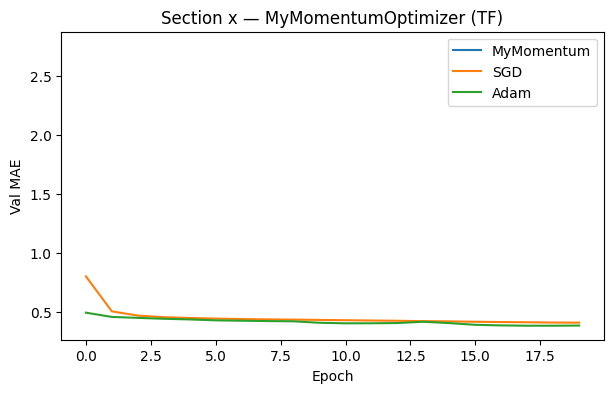

In [ ]:
class MyMomentumOptimizer(keras.optimizers.Optimizer):
    """
    SGD with momentum from scratch (Géron Ch.11).
    Demonstrates the Keras Optimizer API:
    - build(): create velocity variables (one per trainable weight)
    - update_step(): perform the parameter update for one variable
    """
    def __init__(self, learning_rate=0.01, momentum=0.9, name='MyMomentum', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.momentum = momentum

    def build(self, var_list):
        super().build(var_list)
        self._velocities = [
            self.add_variable_from_reference(var, 'velocity')
            for var in var_list
        ]

    def update_step(self, gradient, variable, learning_rate):
        lr = tf.cast(learning_rate, variable.dtype)
        g  = tf.cast(gradient, variable.dtype)
        v  = self._velocities[self._get_variable_index(variable)]
        v.assign(self.momentum * v - lr * g)  # update velocity
        variable.assign_add(v)                # update weights

    def get_config(self):
        return {**super().get_config(), 'momentum': self.momentum}

# Compare MyMomentum vs plain SGD vs Adam
results_opts = {}
for name, opt in [('MyMomentum', MyMomentumOptimizer(1e-2, 0.9)),
                  ('SGD',        keras.optimizers.SGD(1e-2)),
                  ('Adam',       keras.optimizers.Adam(1e-3))]:
    m = make_model(); m.compile(optimizer=opt, loss='mse', metrics=['mae'])
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=20, batch_size=32, verbose=0)
    results_opts[name] = h
    print(f"[{name}] Best val MAE: {min(h.history['val_mae']):.4f}")

plt.figure(figsize=(7,4))
for name, h in results_opts.items():
    plt.plot(h.history['val_mae'], label=name)
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Val MAE')
plt.title('Section x — MyMomentumOptimizer (TF)'); plt.show()


### x.2 — PyTorch

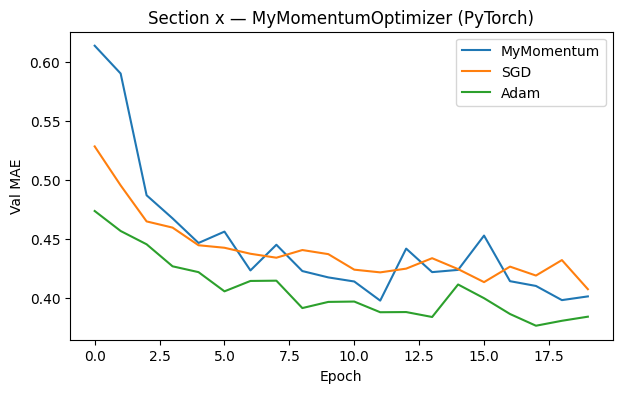

[MyMomentum] Best val MAE: 0.3976
[SGD] Best val MAE: 0.4073
[Adam] Best val MAE: 0.3763


In [ ]:
class MyMomentumOptimizer_PT(optim.Optimizer):
    """
    SGD with momentum from scratch (PyTorch).
    The Optimizer API requires:
    - defaults dict passed to super().__init__()
    - step() method that updates all parameters in param_groups
    - state dict for per-parameter variables (here: velocity)
    """
    def __init__(self, params, lr=0.01, momentum=0.9):
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            lr, mom = group['lr'], group['momentum']
            for p in group['params']:
                if p.grad is None: continue
                # Initialise velocity on first step
                if 'velocity' not in self.state[p]:
                    self.state[p]['velocity'] = torch.zeros_like(p)
                v = self.state[p]['velocity']
                v.mul_(mom).add_(p.grad, alpha=-lr)  # v = mom*v - lr*g
                p.add_(v)                             # w = w + v
        return loss

def train_pt_opt(opt_cls, epochs=20, **kwargs):
    m   = nn.Sequential(nn.Linear(8,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1)).to(DEVICE)
    opt = opt_cls(m.parameters(), **kwargs); val_maes = []
    for ep in range(epochs):
        m.train()
        for xb, yb in ld_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit_mse(m(xb).squeeze(), yb).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            mae = [(m(xb.to(DEVICE)).squeeze()-yb.to(DEVICE)).abs().mean().item() for xb,yb in ld_va]
        val_maes.append(np.mean(mae))
    return val_maes

maes_mymom = train_pt_opt(MyMomentumOptimizer_PT, lr=1e-2, momentum=0.9)
maes_sgd   = train_pt_opt(optim.SGD,  lr=1e-2)
maes_adam  = train_pt_opt(optim.Adam, lr=1e-3)

plt.figure(figsize=(7,4))
plt.plot(maes_mymom, label='MyMomentum')
plt.plot(maes_sgd,   label='SGD')
plt.plot(maes_adam,  label='Adam')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Val MAE')
plt.title('Section x — MyMomentumOptimizer (PyTorch)'); plt.show()
for name, maes in [('MyMomentum', maes_mymom), ('SGD', maes_sgd), ('Adam', maes_adam)]:
    print(f"[{name}] Best val MAE: {min(maes):.4f}")


---
## xi) Custom Training Loop — Fashion MNIST

**What it does:** Replaces `model.fit()` with a manual training loop using `tf.GradientTape`. This gives complete control over:
- When and how gradients are computed and applied
- Gradient clipping
- Custom logic per batch (auxiliary losses, special logging)

**Reference:** Géron Ch. 13 — Fashion MNIST custom training loop.


### xi.1 — TensorFlow GradientTape

In [ ]:
# ── Load Fashion MNIST ──
(fm_xtr, fm_ytr), (fm_xte, fm_yte) = keras.datasets.fashion_mnist.load_data()
fm_xtr = fm_xtr.astype('float32') / 255.0
fm_xte = fm_xte.astype('float32') / 255.0
fm_xtr, fm_xva = fm_xtr[:48000], fm_xtr[48000:]
fm_ytr, fm_yva = fm_ytr[:48000], fm_ytr[48000:]
FM_CLASSES = ['T-shirt','Trouser','Pullover','Dress','Coat',
              'Sandal','Shirt','Sneaker','Bag','Ankle boot']
print(f"Train: {fm_xtr.shape}  Val: {fm_xva.shape}  Test: {fm_xte.shape}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (48000, 28, 28)  Val: (12000, 28, 28)  Test: (10000, 28, 28)


In [ ]:
# ── Model ──
def build_fashion_model():
    return keras.Sequential([
        keras.Input(shape=(28, 28)),
        layers.Reshape((28, 28, 1)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ])

fashion_model = build_fashion_model()
optimizer     = keras.optimizers.Adam(1e-3)
loss_fn       = keras.losses.SparseCategoricalCrossentropy()

train_acc  = keras.metrics.SparseCategoricalAccuracy('train_acc')
val_acc    = keras.metrics.SparseCategoricalAccuracy('val_acc')
train_loss = keras.metrics.Mean('train_loss')
val_loss_m = keras.metrics.Mean('val_loss')

# tf.data pipeline
BATCH = 64
ds_tr = (tf.data.Dataset.from_tensor_slices((fm_xtr, fm_ytr))
         .shuffle(10000).batch(BATCH).prefetch(tf.data.AUTOTUNE))
ds_va = (tf.data.Dataset.from_tensor_slices((fm_xva, fm_yva))
         .batch(BATCH).prefetch(tf.data.AUTOTUNE))

# ── Single train step — compiled to a graph for speed ──
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits = fashion_model(x, training=True)
        loss   = loss_fn(y, logits)
    grads = tape.gradient(loss, fashion_model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)  # gradient clipping
    optimizer.apply_gradients(zip(grads, fashion_model.trainable_variables))
    train_loss.update_state(loss)
    train_acc.update_state(y, logits)

@tf.function
def val_step(x, y):
    logits = fashion_model(x, training=False)
    val_loss_m.update_state(loss_fn(y, logits))
    val_acc.update_state(y, logits)

# ── Custom training loop ──
EPOCHS = 10
history_xi = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0; no_improve = 0; PATIENCE = 3

print(f"{'Epoch':>5}  {'TrainLoss':>10}  {'TrainAcc':>9}  {'ValLoss':>8}  {'ValAcc':>7}")
print('-' * 50)
for epoch in range(EPOCHS):
    for x_batch, y_batch in ds_tr: train_step(x_batch, y_batch)
    for x_batch, y_batch in ds_va: val_step(x_batch,   y_batch)

    tl = train_loss.result().numpy(); ta = train_acc.result().numpy()
    vl = val_loss_m.result().numpy(); va = val_acc.result().numpy()
    print(f"{epoch+1:>5}  {tl:>10.4f}  {ta:>9.4f}  {vl:>8.4f}  {va:>7.4f}")

    history_xi['train_loss'].append(tl); history_xi['train_acc'].append(ta)
    history_xi['val_loss'].append(vl);   history_xi['val_acc'].append(va)

    if va > best_val_acc:
        best_val_acc = va; no_improve = 0
        fashion_model.save_weights('/tmp/best_fashion.weights.h5')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stop at epoch {epoch+1}"); break

    for m in [train_loss, train_acc, val_loss_m, val_acc]: m.reset_state()

fashion_model.load_weights('/tmp/best_fashion.weights.h5')
print(f"Best val accuracy: {best_val_acc:.4f}")


Epoch   TrainLoss   TrainAcc   ValLoss   ValAcc
--------------------------------------------------
    1      0.5231     0.8112    0.3460   0.8735
    2      0.3312     0.8799    0.2882   0.8927
    3      0.2840     0.8950    0.2744   0.9001
    4      0.2549     0.9065    0.2499   0.9084
    5      0.2299     0.9149    0.2409   0.9115
    6      0.2116     0.9215    0.2223   0.9178
    7      0.1917     0.9290    0.2344   0.9157
    8      0.1768     0.9340    0.2332   0.9165
    9      0.1612     0.9409    0.2200   0.9229
   10      0.1480     0.9446    0.2314   0.9250
Best val accuracy: 0.9250


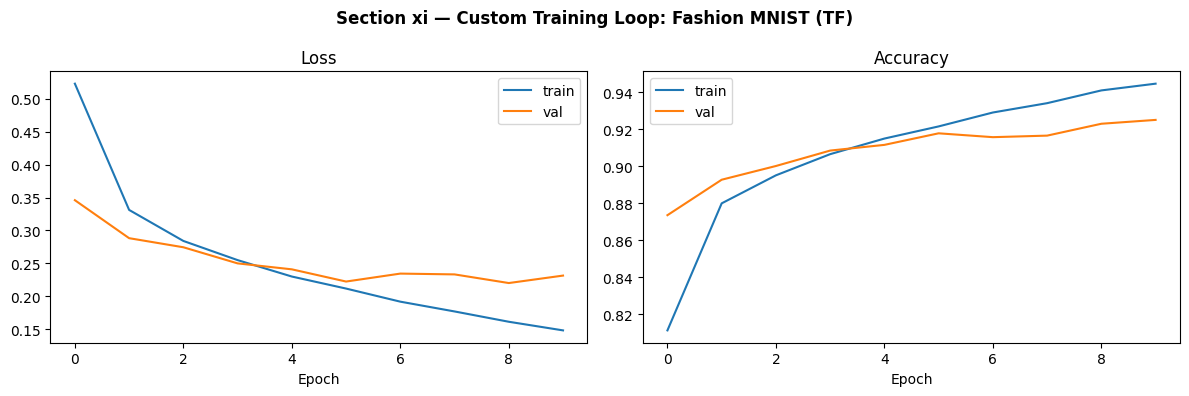

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_xi['train_loss'], label='train'); axes[0].plot(history_xi['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history_xi['train_acc'],  label='train'); axes[1].plot(history_xi['val_acc'],  label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.suptitle('Section xi — Custom Training Loop: Fashion MNIST (TF)', fontweight='bold')
plt.tight_layout(); plt.show()


### xi.2 — PyTorch Custom Training Loop

Epoch   TrainLoss    ValAcc
------------------------------
    1      0.5476    0.8728
    2      0.3441    0.8931
    3      0.2942    0.8979
    4      0.2607    0.9054
    5      0.2353    0.9133
    6      0.2139    0.9125
    7      0.2002    0.9131
    8      0.1885    0.9187
    9      0.1699    0.9208
   10      0.1572    0.9233
Best val accuracy: 0.9233


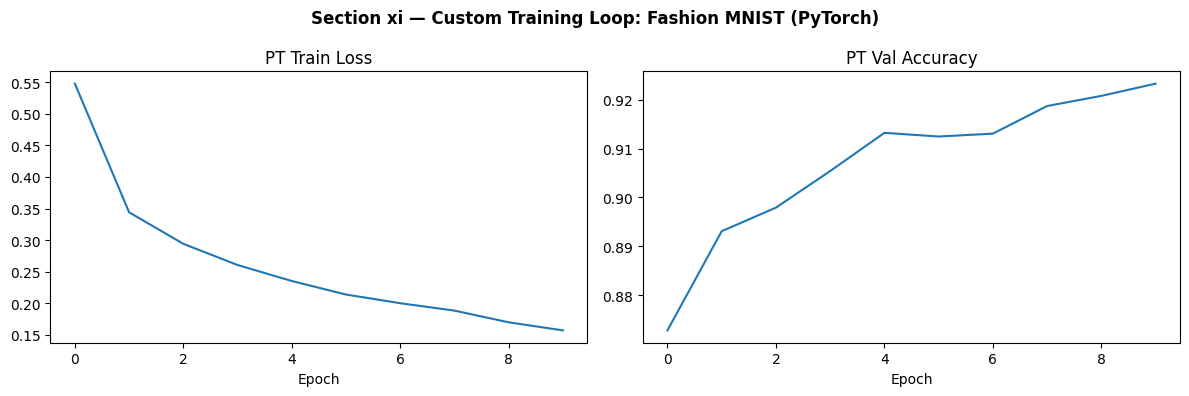

In [ ]:
class FashionCNN_PT(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 10)
        )
    def forward(self, x): return self.head(self.features(x))

class FashionDS(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(1)   # (N, 1, 28, 28)
        self.y = torch.LongTensor(y.astype('int64'))
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

ld_fm_tr = DataLoader(FashionDS(fm_xtr, fm_ytr), 64, shuffle=True)
ld_fm_va = DataLoader(FashionDS(fm_xva, fm_yva), 64)

fm_pt    = FashionCNN_PT().to(DEVICE)
opt_fm   = optim.Adam(fm_pt.parameters(), 1e-3)
crit_ce  = nn.CrossEntropyLoss()
hist_pt  = {'train_loss': [], 'val_acc': []}
best_acc = 0.0; best_wts = None

print(f"{'Epoch':>5}  {'TrainLoss':>10}  {'ValAcc':>8}")
print('-' * 30)
for epoch in range(10):
    fm_pt.train(); tr_loss = 0
    for xb, yb in ld_fm_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_fm.zero_grad()
        loss = crit_ce(fm_pt(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fm_pt.parameters(), 1.0)  # gradient clipping
        opt_fm.step()
        tr_loss += loss.item()
    tr_loss /= len(ld_fm_tr)

    fm_pt.eval(); cor = tot = 0
    with torch.no_grad():
        for xb, yb in ld_fm_va:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            cor += (fm_pt(xb).argmax(1) == yb).sum().item(); tot += len(yb)
    va = cor / tot
    hist_pt['train_loss'].append(tr_loss); hist_pt['val_acc'].append(va)
    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {va:>8.4f}")
    if va > best_acc: best_acc = va; best_wts = copy.deepcopy(fm_pt.state_dict())

fm_pt.load_state_dict(best_wts)
print(f"Best val accuracy: {best_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_pt['train_loss']); axes[0].set_title('PT Train Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(hist_pt['val_acc']);    axes[1].set_title('PT Val Accuracy'); axes[1].set_xlabel('Epoch')
plt.suptitle('Section xi — Custom Training Loop: Fashion MNIST (PyTorch)', fontweight='bold')
plt.tight_layout(); plt.show()


---
## xii) ML Training with Weights & Biases

**What it does:** Weights & Biases (W&B) is an experiment tracking platform. Every run logs:
- Hyperparameters (`config`)
- Metrics per epoch (`wandb.log`)
- Model artifacts (saved model files)
- System metrics (GPU, CPU, memory)

You can then compare runs, find the best hyperparameters, and share results with a team.

**Setup:** Create a free account at https://wandb.ai, then run `wandb login`.
For anonymous/demo usage (no login), set `mode='offline'` or `anonymous='allow'`.


### xii.1 — TensorFlow + W&B

In [ ]:
import wandb
from wandb.integration.keras import WandbMetricsLogger

# Login — anonymous mode works without an account for demo purposes
wandb.login(anonymous='allow')

# Define the run configuration
config = {
    'architecture' : 'ResidualRegressor',
    'n_blocks'     : 3,
    'units'        : 64,
    'optimizer'    : 'adam',
    'learning_rate': 1e-3,
    'loss'         : 'huber_delta1',
    'batch_size'   : 32,
    'epochs'       : 20,
    'dataset'      : 'california_housing',
}

# Initialise a W&B run
run = wandb.init(
    project = 'advanced-keras-demo',
    name    = 'residual-regressor-run',
    config  = config,
)

# Build and train model
wb_model = ResidualRegressor(n_blocks=config['n_blocks'], units=config['units'])
wb_model.compile(
    optimizer = keras.optimizers.Adam(config['learning_rate']),
    loss      = HuberLoss(delta=1.0),
    metrics   = [HuberMetric(delta=1.0), 'mae'],
)

wb_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs     = config['epochs'],
    batch_size = config['batch_size'],
    verbose    = 0,
    callbacks  = [
        WandbMetricsLogger(log_freq='epoch'),   # logs all Keras metrics to W&B automatically
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    ],
)

# Log a summary stat
wandb.summary['best_val_mae'] = min(wb_model.history.history['val_mae'])
run.finish()
print(f"Run finished. View at: {run.url}")


wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: keerthana-m (keerthana-m-san-jose-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/huber_metric,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/mae,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_huber_metric,█▅▆▄▃▂▂▂▂▂▂▁▁▂▁▂▁▂▁▁
epoch/val_loss,█▅▆▄▃▂▂▂▂▂▂▁▁▂▁▂▁▂▁▁
epoch/val_mae,█▅▄▄▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁
best_val_mae,0.87513
epoch/epoch,19
epoch/huber_metric,0.50695


Run finished. View at: https://wandb.ai/keerthana-m-san-jose-state-university/advanced-keras-demo/runs/yixc9f5l


### xii.2 — PyTorch + W&B with Hyperparameter Sweep

In [ ]:
def train_wandb_pt(config=None):
    """
    Single training function called by wandb.agent during a sweep.
    wandb.init() is used as a context manager — it automatically
    captures all logged values and associates them with the run.
    """
    with wandb.init(config=config, project='advanced-pytorch-demo') as run:
        cfg = wandb.config

        model = nn.Sequential(
            nn.Linear(8, cfg.hidden),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden, cfg.hidden // 2),
            nn.ReLU(),
            nn.Linear(cfg.hidden // 2, 1),
        ).to(DEVICE)

        opt   = optim.Adam(model.parameters(), lr=cfg.lr)
        loss_fn = HuberLoss_PT(delta=cfg.delta)
        ld_tr_ = DataLoader(TensorDataset(Xt, yt), cfg.batch_size, shuffle=True)
        ld_va_ = DataLoader(TensorDataset(Xv, yv), cfg.batch_size)

        # wandb.watch logs gradients and weight histograms
        wandb.watch(model, log='gradients', log_freq=20)

        for ep in range(cfg.epochs):
            model.train(); tr_loss = 0
            for xb, yb in ld_tr_:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); loss_fn(model(xb).squeeze(), yb).backward(); opt.step()
                tr_loss += loss_fn(model(xb).squeeze(), yb).item()
            tr_loss /= len(ld_tr_)

            model.eval()
            with torch.no_grad():
                val_mae = np.mean([(model(xb.to(DEVICE)).squeeze() - yb.to(DEVICE)).abs().mean().item()
                                   for xb, yb in ld_va_])

            # Log metrics for this epoch
            wandb.log({'epoch': ep, 'train_loss': tr_loss, 'val_mae': val_mae})


# ── Single run ──
single_config = dict(hidden=128, dropout=0.2, lr=1e-3, delta=1.0, batch_size=32, epochs=15)
train_wandb_pt(single_config)
print("Single run complete.")


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_loss,█▃▃▂▂▂▂▁▁▁▁▁▁▁▁
val_mae,█▆▆▅▄▃▂▂▃▁▂▃▁▃▁
epoch,14
train_loss,0.13105
val_mae,0.3762


Single run complete.


In [ ]:
# ── Hyperparameter Sweep ──
# W&B sweep tries different combinations of hyperparameters automatically.
# 'random' method samples randomly; alternatives are 'grid' and 'bayes'.

sweep_config = {
    'method': 'random',
    'metric': {'name': 'val_mae', 'goal': 'minimize'},
    'parameters': {
        'hidden':     {'values': [64, 128, 256]},
        'dropout':    {'values': [0.1, 0.2, 0.4]},
        'lr':         {'values': [1e-4, 1e-3, 5e-3]},
        'delta':      {'values': [0.5, 1.0, 2.0]},
        'batch_size': {'values': [32, 64]},
        'epochs':     {'value' : 10},
    }
}

sweep_id = wandb.sweep(sweep_config, project='advanced-pytorch-demo')
print(f"Sweep ID: {sweep_id}")
print("Running 3 trials...")
wandb.agent(sweep_id, function=train_wandb_pt, count=3)
print("Sweep complete. View results at https://wandb.ai")


Create sweep with ID: 2pbdnxlh
Sweep URL: https://wandb.ai/keerthana-m-san-jose-state-university/advanced-pytorch-demo/sweeps/2pbdnxlh
Sweep ID: 2pbdnxlh
Running 3 trials...


wandb: Agent Starting Run: xxwktcxo with config:
wandb: 	batch_size: 32
wandb: 	delta: 0.5
wandb: 	dropout: 0.2
wandb: 	epochs: 10
wandb: 	hidden: 128
wandb: 	lr: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▂▂▁▁▁
val_mae,█▅▅▄▃▂▂▂▁▁
epoch,9
train_loss,0.102
val_mae,0.37739


wandb: Agent Starting Run: s5p9wo5z with config:
wandb: 	batch_size: 64
wandb: 	delta: 1
wandb: 	dropout: 0.1
wandb: 	epochs: 10
wandb: 	hidden: 128
wandb: 	lr: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▂▂▂▁▁▁▁▁
val_mae,█▇▅▃▄▄▃▁▁▂
epoch,9
train_loss,0.14012
val_mae,0.3926


wandb: Agent Starting Run: 6yswrtdr with config:
wandb: 	batch_size: 32
wandb: 	delta: 2
wandb: 	dropout: 0.4
wandb: 	epochs: 10
wandb: 	hidden: 64
wandb: 	lr: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▂▂▂▂▁▁▁▁
val_mae,█▆▅▄█▂▃▂▁▁
epoch,9
train_loss,0.17432
val_mae,0.40603


Sweep complete. View results at https://wandb.ai


---
## Summary

| Section | Technique | TF/Keras | PyTorch |
|---|---|---|---|
| i | OneCycleScheduler | `keras.callbacks.Callback`, sets `optimizer.learning_rate` each batch | Subclasses `optim.lr_scheduler._LRScheduler`, implements `get_lr()` |
| ii | MCAlphaDropout | `layers.Layer`, active at inference with `training=True` | `nn.Module` with `mc=True` flag |
| iii | MaxNormDense | `layers.Layer`, clips kernel column norms in `call()` | `nn.Module`, clips weight row norms in `forward()` |
| iv | TensorBoard | `keras.callbacks.TensorBoard` | `torch.utils.tensorboard.SummaryWriter` |
| v | HuberLoss | Subclasses `keras.losses.Loss`, implements `call()` | Subclasses `nn.Module`, implements `forward()` |
| vi | Activation/Init/Reg/Constraint | Function + `Initializer` + `Regularizer` + `Constraint` subclasses | Functions + `apply()` + added to loss manually |
| vii | HuberMetric | Subclasses `keras.metrics.Metric` with `update_state/result/reset_state` | Stateful class with `update/result/reset` |
| viii | Custom Layers | `ExponentialLayer`, `MyDense`, `AddGaussianNoise`, `MyLayerNorm` | Same four as `nn.Module` subclasses |
| ix | ResidualRegressor | `ResidualBlock` as `layers.Layer` + `ResidualRegressor` as `keras.Model` | Same as `nn.Module` subclasses |
| x | MyMomentumOptimizer | Subclasses `keras.optimizers.Optimizer`, implements `build/update_step` | Subclasses `optim.Optimizer`, implements `step()` |
| xi | Custom Training Loop | `@tf.function` + `GradientTape` + `clip_by_global_norm` | Manual loop + `clip_grad_norm_` |
| xii | Weights & Biases | `WandbMetricsLogger` callback + `wandb.init/log/summary` | `wandb.watch` + `wandb.log` + hyperparameter sweep |
